In [6]:
# NEO TELECOM CUSTOMER CHURN PREDICTION PROJECT

import pandas as pd
import numpy as np
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("=== NEO TELECOM CUSTOMER CHURN ANALYSIS ===")

# STEP 1: LOAD DATASET FROM ZIP - FIXED VERSION
with zipfile.ZipFile('Capstone-project-2.zip', 'r') as z:
    file_list = z.namelist()
    print("Files inside zip:", file_list)

    # Find CSV file even if inside folder
    csv_files = [f for f in file_list if f.endswith('.csv')]

    if len(csv_files) == 0:
        raise Exception("No CSV file found in zip. Check zip contents.")

    csv_file = csv_files[0]
    print(f"Loading file: {csv_file}")

    with z.open(csv_file) as f:
        churn_df = pd.read_csv(f)

print("Dataset Loaded Successfully")
print(f"Shape: {churn_df.shape}")
print(churn_df.head())

# STEP 2: PART A - DATA CLEANING
print("\n--- PART A: DATA CLEANING ---")
churn_df['TotalCharges'] = pd.to_numeric(churn_df['TotalCharges'], errors='coerce')
churn_df['TotalCharges'].fillna(churn_df['TotalCharges'].median(), inplace=True)
churn_df.drop('customerID', axis=1, inplace=True)
print("Missing values:", churn_df.isnull().sum().sum())
print("Data cleaned. New shape:", churn_df.shape)

# STEP 3: PART B - EDA VISUALIZATIONS
print("\n--- PART B: EDA ---")
churn_rate = churn_df['Churn'].value_counts(normalize=True) * 100
print(f"Churn Rate: {churn_rate['Yes']:.2f}%")

plt.figure(figsize=(15,10))

plt.subplot(2,2,1)
sns.countplot(data=churn_df, x='Churn', palette='Set2')
plt.title('Churn Distribution')

plt.subplot(2,2,2)
sns.boxplot(data=churn_df, x='Churn', y='tenure', palette='Set3')
plt.title('Tenure vs Churn')

plt.subplot(2,2,3)
sns.countplot(data=churn_df, x='Contract', hue='Churn', palette='coolwarm')
plt.title('Contract Type vs Churn')

plt.subplot(2,2,4)
sns.histplot(data=churn_df, x='MonthlyCharges', hue='Churn', kde=True, palette='viridis')
plt.title('Monthly Charges vs Churn')

plt.tight_layout()
plt.show()

# STEP 4: PART D - MACHINE LEARNING
print("\n--- PART D: MACHINE LEARNING ---")

df_model = churn_df.copy()
le = LabelEncoder()
for col in df_model.select_dtypes(include=['object']).columns:
    df_model[col] = le.fit_transform(df_model[col])

X = df_model.drop('Churn', axis=1)
y = df_model['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print(f"Logistic Regression Accuracy: {lr_acc*100:.2f}%")
print(f"Random Forest Accuracy: {rf_acc*100:.2f}%")

best_pred = rf_pred if rf_acc > lr_acc else lr_pred
best_model_name = "Random Forest" if rf_acc > lr_acc else "Logistic Regression"

print(f"\nBest Model: {best_model_name}")
print("\nClassification Report:")
print(classification_report(y_test, best_pred))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, best_pred), annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print("\n=== PROJECT COMPLETED ===")

=== NEO TELECOM CUSTOMER CHURN ANALYSIS ===
Files inside zip: ['Dataset.zip', 'Python-Final-Project-Description.docx', 'solution.zip']


Exception: No CSV file found in zip. Check zip contents.

In [7]:
import zipfile

with zipfile.ZipFile('Capstone-project-2.zip', 'r') as zip_ref:
    zip_ref.extractall()
    print("Extracted successfully")
    print("Files:", zip_ref.namelist())

Extracted successfully
Files: ['Dataset.zip', 'Python-Final-Project-Description.docx', 'solution.zip']


=== NEO TELECOM CUSTOMER CHURN ANALYSIS ===
Files inside Dataset.zip: ['Dataset/', 'Dataset/customer_churn.csv']
Loading file: Dataset/customer_churn.csv
Dataset Loaded Successfully
Shape: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone ser

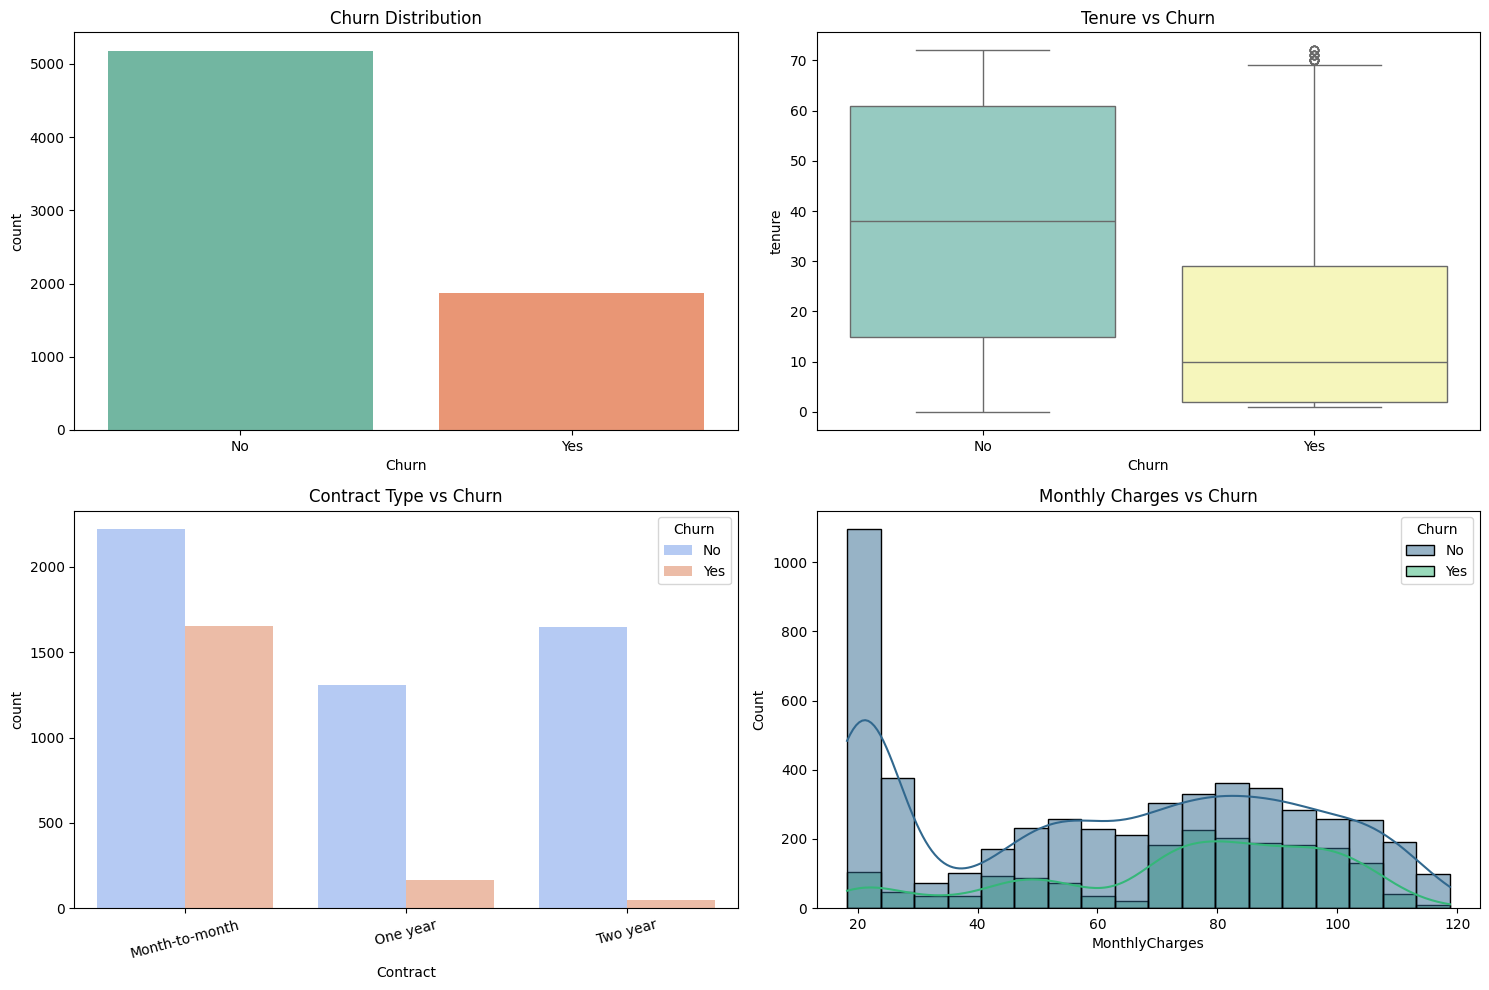


--- PART D: MACHINE LEARNING ---
Logistic Regression Accuracy: 81.62%
Random Forest Accuracy: 79.56%

Best Model: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.58      0.62       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



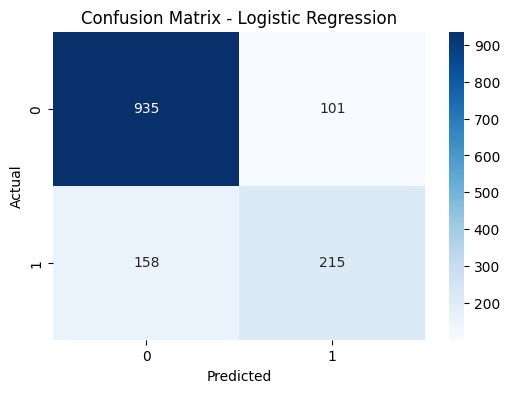


=== PROJECT COMPLETED ===


In [8]:
# NEO TELECOM CUSTOMER CHURN PREDICTION PROJECT

import pandas as pd
import numpy as np
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("=== NEO TELECOM CUSTOMER CHURN ANALYSIS ===")

# STEP 1: LOAD FROM Dataset.zip
with zipfile.ZipFile('Dataset.zip', 'r') as z:
    file_list = z.namelist()
    print("Files inside Dataset.zip:", file_list)

    csv_file = [f for f in file_list if f.endswith('.csv')][0]
    print(f"Loading file: {csv_file}")

    with z.open(csv_file) as f:
        churn_df = pd.read_csv(f)

print("Dataset Loaded Successfully")
print(f"Shape: {churn_df.shape}")
print(churn_df.head())

# STEP 2: PART A - DATA CLEANING
print("\n--- PART A: DATA CLEANING ---")
churn_df['TotalCharges'] = pd.to_numeric(churn_df['TotalCharges'], errors='coerce')
churn_df['TotalCharges'].fillna(churn_df['TotalCharges'].median(), inplace=True)
churn_df.drop('customerID', axis=1, inplace=True)
print("Missing values:", churn_df.isnull().sum().sum())
print("Data cleaned. New shape:", churn_df.shape)

# STEP 3: PART B - EDA VISUALIZATIONS
print("\n--- PART B: EDA ---")
churn_rate = churn_df['Churn'].value_counts(normalize=True) * 100
print(f"Churn Rate: {churn_rate['Yes']:.2f}%")

plt.figure(figsize=(15,10))

plt.subplot(2,2,1)
sns.countplot(data=churn_df, x='Churn', palette='Set2')
plt.title('Churn Distribution')

plt.subplot(2,2,2)
sns.boxplot(data=churn_df, x='Churn', y='tenure', palette='Set3')
plt.title('Tenure vs Churn')

plt.subplot(2,2,3)
sns.countplot(data=churn_df, x='Contract', hue='Churn', palette='coolwarm')
plt.title('Contract Type vs Churn')
plt.xticks(rotation=15)

plt.subplot(2,2,4)
sns.histplot(data=churn_df, x='MonthlyCharges', hue='Churn', kde=True, palette='viridis')
plt.title('Monthly Charges vs Churn')

plt.tight_layout()
plt.show()

# STEP 4: PART D - MACHINE LEARNING
print("\n--- PART D: MACHINE LEARNING ---")

df_model = churn_df.copy()
le = LabelEncoder()
for col in df_model.select_dtypes(include=['object']).columns:
    df_model[col] = le.fit_transform(df_model[col])

X = df_model.drop('Churn', axis=1)
y = df_model['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print(f"Logistic Regression Accuracy: {lr_acc*100:.2f}%")
print(f"Random Forest Accuracy: {rf_acc*100:.2f}%")

best_pred = rf_pred if rf_acc > lr_acc else lr_pred
best_model_name = "Random Forest" if rf_acc > lr_acc else "Logistic Regression"

print(f"\nBest Model: {best_model_name}")
print("\nClassification Report:")
print(classification_report(y_test, best_pred))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, best_pred), annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print("\n=== PROJECT COMPLETED ===")

=== NEO TELECOM CUSTOMER CHURN ANALYSIS ===
Files inside Dataset.zip: ['Dataset/', 'Dataset/customer_churn.csv']
Loading file: Dataset/customer_churn.csv
Dataset Loaded Successfully
Shape: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone ser

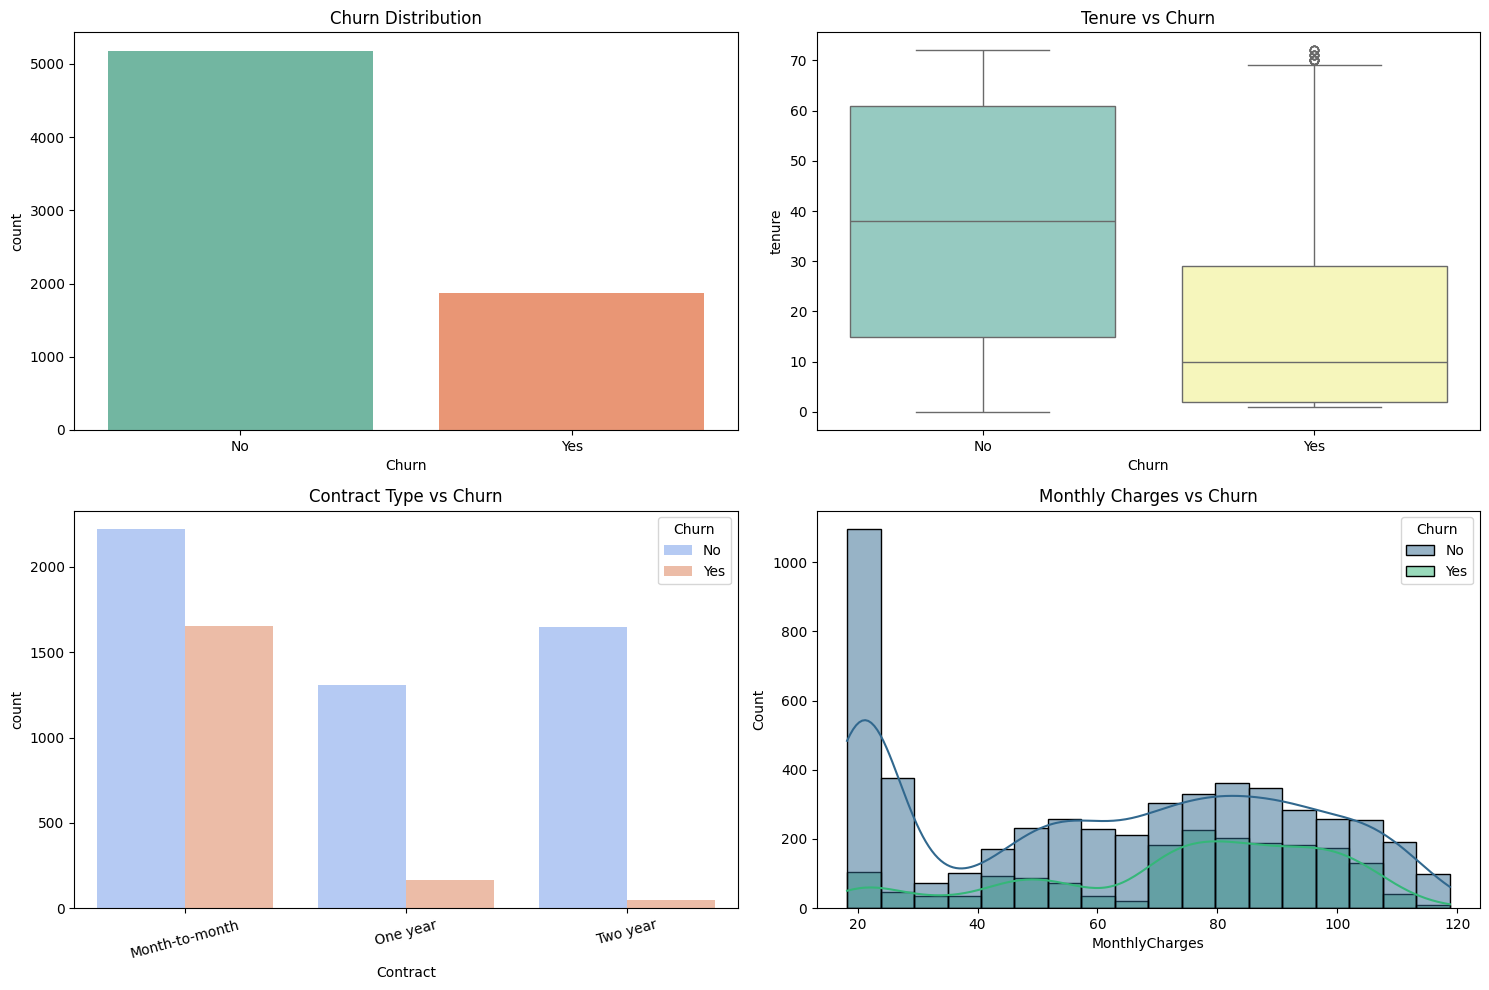


--- PART D: MACHINE LEARNING ---
Logistic Regression Accuracy: 81.62%
Random Forest Accuracy: 79.56%

Best Model: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.58      0.62       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



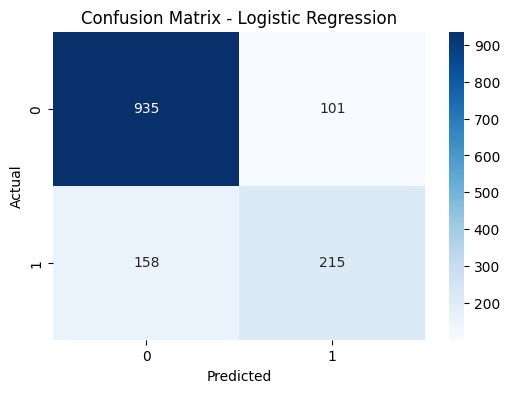


=== PROJECT COMPLETED ===


In [9]:
# NEO TELECOM CUSTOMER CHURN PREDICTION PROJECT

import pandas as pd
import numpy as np
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("=== NEO TELECOM CUSTOMER CHURN ANALYSIS ===")

# STEP 1: LOAD FROM Dataset.zip
with zipfile.ZipFile('Dataset.zip', 'r') as z:
    file_list = z.namelist()
    print("Files inside Dataset.zip:", file_list)

    csv_file = [f for f in file_list if f.endswith('.csv')][0]
    print(f"Loading file: {csv_file}")

    with z.open(csv_file) as f:
        churn_df = pd.read_csv(f)

print("Dataset Loaded Successfully")
print(f"Shape: {churn_df.shape}")
print(churn_df.head())

# STEP 2: PART A - DATA CLEANING
print("\n--- PART A: DATA CLEANING ---")
churn_df['TotalCharges'] = pd.to_numeric(churn_df['TotalCharges'], errors='coerce')
churn_df['TotalCharges'].fillna(churn_df['TotalCharges'].median(), inplace=True)
churn_df.drop('customerID', axis=1, inplace=True)
print("Missing values:", churn_df.isnull().sum().sum())
print("Data cleaned. New shape:", churn_df.shape)

# STEP 3: PART B - EDA VISUALIZATIONS
print("\n--- PART B: EDA ---")
churn_rate = churn_df['Churn'].value_counts(normalize=True) * 100
print(f"Churn Rate: {churn_rate['Yes']:.2f}%")

plt.figure(figsize=(15,10))

plt.subplot(2,2,1)
sns.countplot(data=churn_df, x='Churn', palette='Set2')
plt.title('Churn Distribution')

plt.subplot(2,2,2)
sns.boxplot(data=churn_df, x='Churn', y='tenure', palette='Set3')
plt.title('Tenure vs Churn')

plt.subplot(2,2,3)
sns.countplot(data=churn_df, x='Contract', hue='Churn', palette='coolwarm')
plt.title('Contract Type vs Churn')
plt.xticks(rotation=15)

plt.subplot(2,2,4)
sns.histplot(data=churn_df, x='MonthlyCharges', hue='Churn', kde=True, palette='viridis')
plt.title('Monthly Charges vs Churn')

plt.tight_layout()
plt.show()

# STEP 4: PART D - MACHINE LEARNING
print("\n--- PART D: MACHINE LEARNING ---")

df_model = churn_df.copy()
le = LabelEncoder()
for col in df_model.select_dtypes(include=['object']).columns:
    df_model[col] = le.fit_transform(df_model[col])

X = df_model.drop('Churn', axis=1)
y = df_model['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print(f"Logistic Regression Accuracy: {lr_acc*100:.2f}%")
print(f"Random Forest Accuracy: {rf_acc*100:.2f}%")

best_pred = rf_pred if rf_acc > lr_acc else lr_pred
best_model_name = "Random Forest" if rf_acc > lr_acc else "Logistic Regression"

print(f"\nBest Model: {best_model_name}")
print("\nClassification Report:")
print(classification_report(y_test, best_pred))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, best_pred), annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print("\n=== PROJECT COMPLETED ===")